# Classifier Training — XGBoost Human-Likelihood Scoring

This notebook walks through the full training and evaluation pipeline for the **Hidden Scoring Module** — an XGBoost binary classifier that scores browser sessions as human (1.0) or bot (0.0) based on 39 aggregate telemetry features.

### What this notebook does
- Loads session data **directly from `src/data/`** (human, bot, and optionally augmented-bot).
- Explores the dataset composition, class balance, and raw feature distributions.
- Extracts the 39-dimensional feature vector per session and visualizes feature importance.
- Trains **four model variants** to compare augmentation strategies:
  1. **Baseline** — no augmentation
  2. **Noise-augmented** — multi-copy Gaussian feature noise
  3. **Adversarial-augmented** — humanized bot copies (feature-level)
  4. **Full pipeline** — noise + adversarial + label smoothing (default config)
- Evaluates each variant on a held-out test set with confusion matrices, ROC curves, and score distributions.
- Compares all four variants side-by-side.
- Saves all figures to `notebook_figures/`.

### How to use this notebook
Run cells from top to bottom. Training is fast (seconds, not minutes) since XGBoost operates on tabular features. To reproduce full hyperparameter-tuned results, use the `train_classifier.py` CLI script with `--tune`.

---
## 1. Setup

Import libraries, resolve paths, and create the figures output directory.

In [ ]:
# Standard library
from pathlib import Path
from collections import defaultdict
from dataclasses import replace

# Core data science stack
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities for splitting, metrics, and scaling
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
)

# Render plots inline
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

In [ ]:
# This notebook lives at src/classifier_training.ipynb
NOTEBOOK_DIR = Path.cwd()
# Root of all telemetry data — subfolders: human/, bot/, bot_augmented/
DATA_DIR = NOTEBOOK_DIR / "data"
# Output directory for all autogenerated figures
FIGURES_DIR = NOTEBOOK_DIR / "notebook_figures"
FIGURES_DIR.mkdir(exist_ok=True)
# Fail fast if data is missing
assert DATA_DIR.is_dir(), f"Data directory not found: {DATA_DIR}"

print(f"Notebook dir : {NOTEBOOK_DIR}")
print(f"Data dir     : {DATA_DIR}")
print(f"Figures dir  : {FIGURES_DIR}")

Notebook dir : /Users/martintran/senior_project/group-project-team-25/src
Data dir     : /Users/martintran/senior_project/group-project-team-25/src/data
Figures dir  : /Users/martintran/senior_project/group-project-team-25/src/notebook_figures


---
## 2. Load the Data

The `load_from_directory` helper reads every JSON file under `data/human/` (label=1) and `data/bot/` (label=0). Each file is normalized into a `Session` dataclass containing mouse, click, keystroke, and scroll event lists plus metadata. With `include_augmented=True`, pre-generated humanized bot sessions from `data/bot_augmented/` are also loaded.

In [ ]:
# Import the classifier's own data loader and feature extractor
from classifier.data_loader import load_from_directory, is_augmented, Session
from classifier.features import SessionFeatureExtractor, FEATURE_NAMES, FEATURE_DIM
from classifier.model import HumanLikelihoodClassifier
from classifier.augmentation import adversarial_augment_sessions
from rl_captcha.config import ClassifierConfig

# Load all sessions (including any pre-generated augmented bot sessions)
sessions = load_from_directory(DATA_DIR, include_augmented=True)
print(f"Loaded {len(sessions)} sessions total")

  Loaded 2610 augmented bot sessions from /Users/martintran/senior_project/group-project-team-25/src/data/bot_augmented/
Loaded 3248 sessions total


In [ ]:
# Split sessions by label to inspect class balance
human_sessions = [s for s in sessions if s.label == 1]
bot_sessions = [s for s in sessions if s.label == 0]
aug_sessions = [s for s in bot_sessions if is_augmented(s)]
orig_bot_sessions = [s for s in bot_sessions if not is_augmented(s)]
# Original (non-augmented) sessions only — used for train/test splits
originals = [s for s in sessions if s.label is not None and not is_augmented(s)]

print(f"Human sessions      : {len(human_sessions)}")
print(f"Bot sessions (orig) : {len(orig_bot_sessions)}")
print(f"Bot sessions (aug)  : {len(aug_sessions)}")
print(f"Originals total     : {len(originals)}")

Human sessions      : 202
Bot sessions (orig) : 436
Bot sessions (aug)  : 2610
Originals total     : 638


### 2.1 Dataset composition
Bar chart of the three session categories. Saved to `notebook_figures/clf_01_dataset_composition.png`.

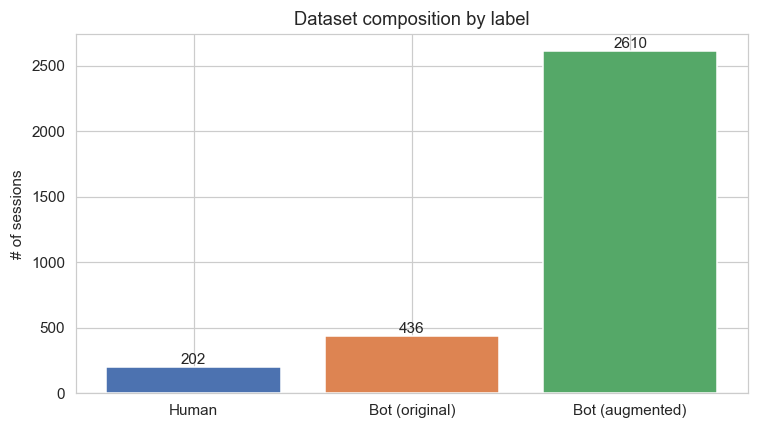

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
categories = ["Human", "Bot (original)", "Bot (augmented)"]
counts = [len(human_sessions), len(orig_bot_sessions), len(aug_sessions)]
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax.bar(categories, counts, color=colors)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(c),
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("# of sessions")
ax.set_title("Dataset composition by label")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clf_01_dataset_composition.png")
plt.show()

### 2.2 Raw event-count distribution
How much telemetry does each session contain? Histogram of total event count per session, split by label.

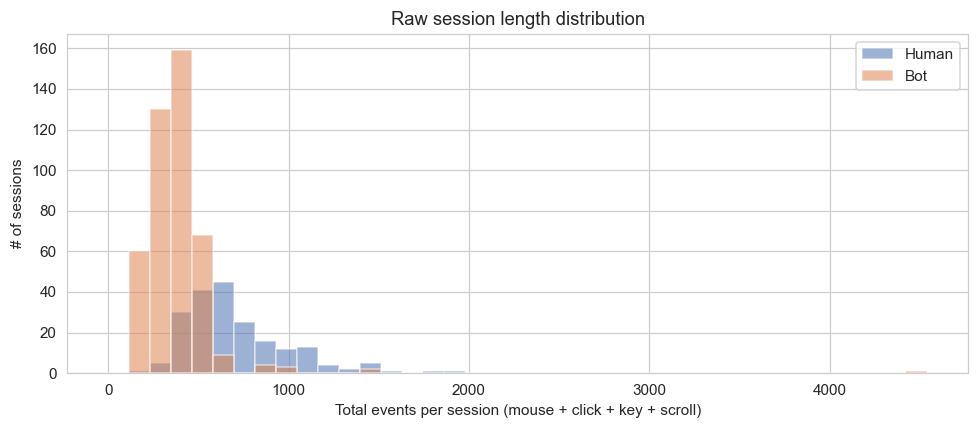

In [ ]:
def _total_events(s):
    return len(s.mouse) + len(s.clicks) + len(s.keystrokes) + len(s.scroll)

human_lens = np.array([_total_events(s) for s in human_sessions])
bot_lens = np.array([_total_events(s) for s in orig_bot_sessions])

fig, ax = plt.subplots(figsize=(9, 4))
max_len = max(human_lens.max() if len(human_lens) else 0,
              bot_lens.max() if len(bot_lens) else 0)
bins = np.linspace(0, max_len + 1, 40)
ax.hist(human_lens, bins=bins, alpha=0.55, label="Human", color="#4C72B0")
ax.hist(bot_lens, bins=bins, alpha=0.55, label="Bot", color="#DD8452")
ax.set_xlabel("Total events per session (mouse + click + key + scroll)")
ax.set_ylabel("# of sessions")
ax.set_title("Raw session length distribution")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clf_02_event_counts.png")
plt.show()

---
## 3. Feature Extraction

The `SessionFeatureExtractor` converts each session into a **39-dimensional** numeric vector covering:
- **Mouse (9):** count, avg/std speed, avg/std dt, direction changes, straightness, jitter, acceleration std
- **Click (4):** count, avg/std interval, interactive target ratio
- **Keystroke (8):** count, avg/std interval, unique fields, field switches, rhythm regularity, avg/std hold
- **Scroll (6):** count, avg/std dy, total abs scroll, avg speed, direction changes
- **Session (1):** duration
- **Event ratios (4):** mouse/click/key/scroll fractions
- **Global timing (3):** mean/var/min inter-event dt
- **Spatial (4):** unique x/y positions, x/y range

In [ ]:
# Extract features for all original (non-augmented) sessions
extractor = SessionFeatureExtractor()
X_all = extractor.extract_many(originals)
y_all = np.array([s.label for s in originals], dtype=int)

print(f"Feature matrix shape: {X_all.shape}  (sessions x features)")
print(f"Feature dimension   : {FEATURE_DIM}")
print(f"Class distribution  : {dict(zip(*np.unique(y_all, return_counts=True)))}")
print(f"\nFeature names ({len(FEATURE_NAMES)}):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  [{i:2d}] {name}")

Feature matrix shape: (638, 39)  (sessions x features)
Feature dimension   : 39
Class distribution  : {0: 436, 1: 202}

Feature names (39):
  [ 0] mouse_count
  [ 1] mouse_avg_speed
  [ 2] mouse_std_speed
  [ 3] mouse_avg_dt
  [ 4] mouse_std_dt
  [ 5] mouse_direction_change_ratio
  [ 6] mouse_straightness
  [ 7] mouse_jitter_ratio
  [ 8] mouse_acceleration_std
  [ 9] click_count
  [10] click_avg_interval
  [11] click_std_interval
  [12] click_interactive_ratio
  [13] keystroke_count
  [14] keystroke_avg_interval
  [15] keystroke_std_interval
  [16] keystroke_unique_fields
  [17] keystroke_field_switch_ratio
  [18] keystroke_rhythm_regularity
  [19] keystroke_avg_hold_duration
  [20] keystroke_std_hold_duration
  [21] scroll_count
  [22] scroll_avg_dy
  [23] scroll_std_dy
  [24] scroll_total_abs
  [25] scroll_avg_speed
  [26] scroll_direction_change_ratio
  [27] session_duration
  [28] event_ratio_mouse
  [29] event_ratio_click
  [30] event_ratio_key
  [31] event_ratio_scroll
  [32] glo

### 3.1 Feature distributions: Human vs Bot
The 39 features capture behavioral patterns. Bots typically have **low speed variance, uniform keystroke timing, and straighter mouse paths** than humans. We plot the top 12 most discriminative features.

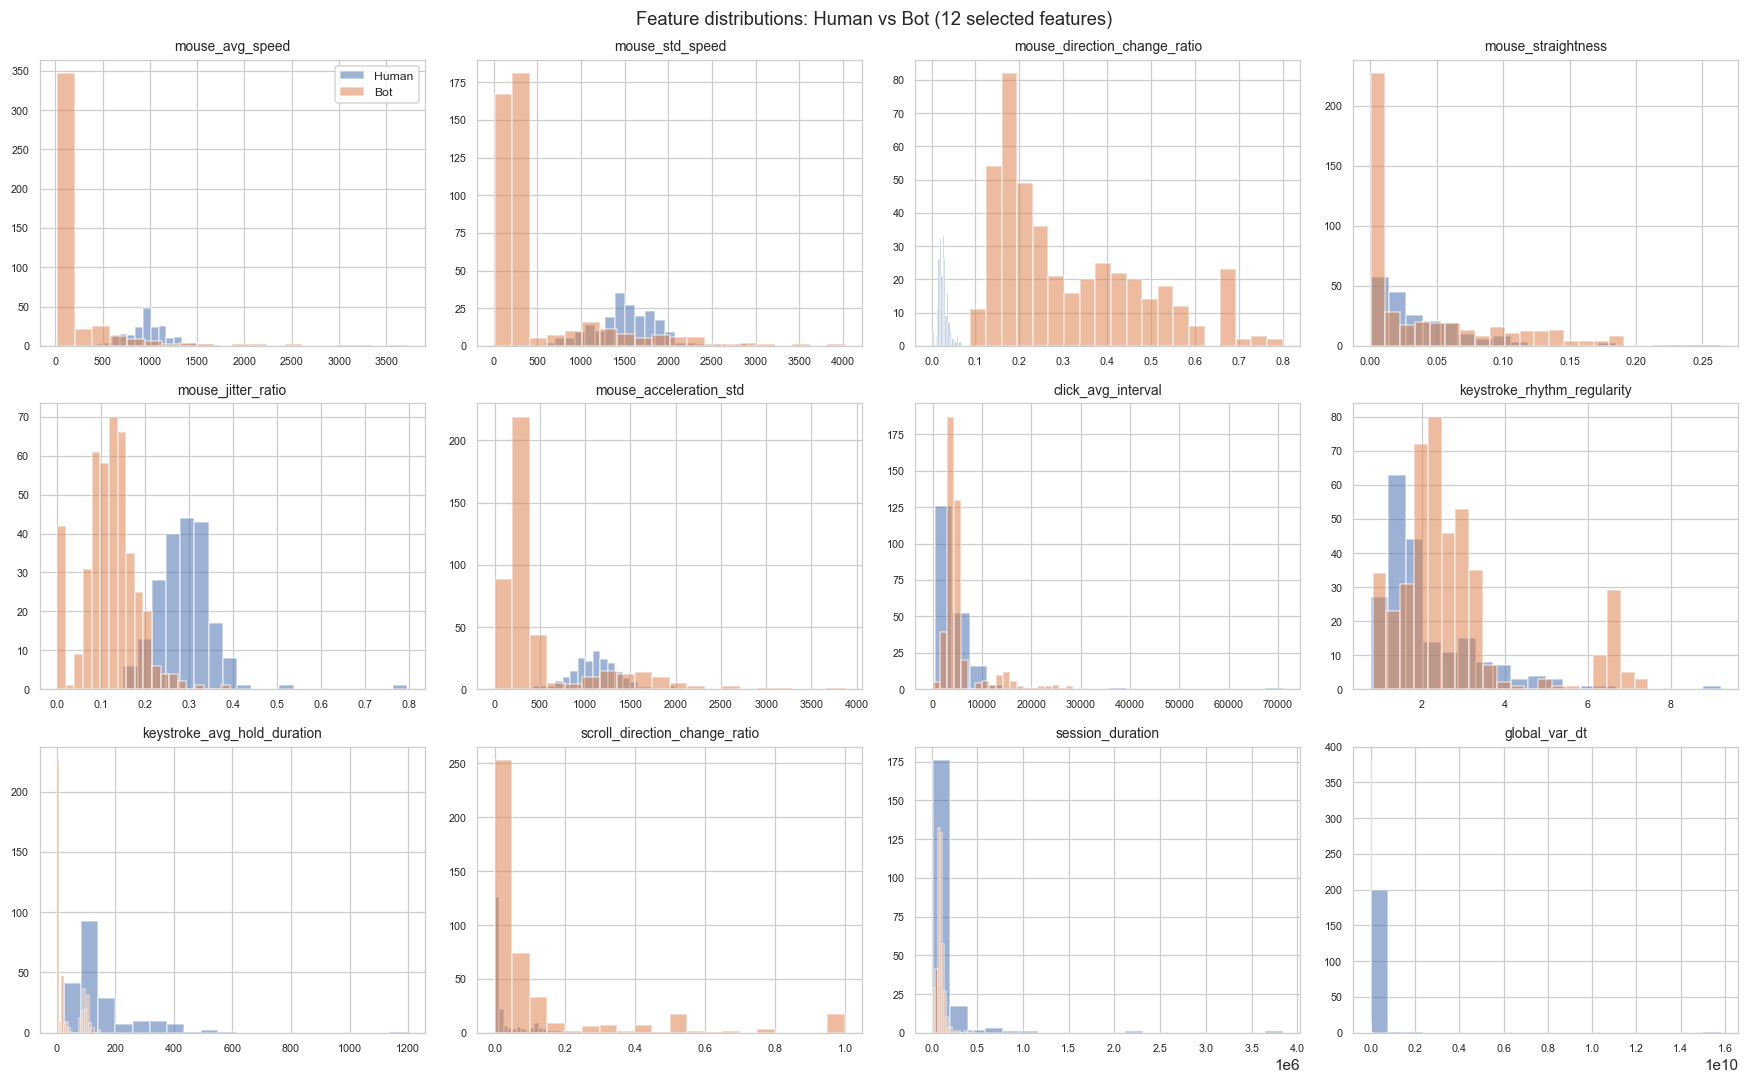

In [ ]:
# Select 12 representative features across all signal groups
selected_features = [
    "mouse_avg_speed", "mouse_std_speed", "mouse_direction_change_ratio",
    "mouse_straightness", "mouse_jitter_ratio", "mouse_acceleration_std",
    "click_avg_interval", "keystroke_rhythm_regularity",
    "keystroke_avg_hold_duration", "scroll_direction_change_ratio",
    "session_duration", "global_var_dt",
]
selected_idx = [FEATURE_NAMES.index(n) for n in selected_features]

human_mask = y_all == 1
bot_mask = y_all == 0

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, (ax, feat_idx) in enumerate(zip(axes.ravel(), selected_idx)):
    ax.hist(X_all[human_mask, feat_idx], bins=20, alpha=0.55, color="#4C72B0", label="Human")
    ax.hist(X_all[bot_mask, feat_idx], bins=20, alpha=0.55, color="#DD8452", label="Bot")
    ax.set_title(FEATURE_NAMES[feat_idx], fontsize=9)
    ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Feature distributions: Human vs Bot (12 selected features)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clf_03_feature_distributions.png")
plt.show()

### 3.2 Feature correlation heatmap
Visualize the Pearson correlation matrix to identify redundant or highly correlated features.

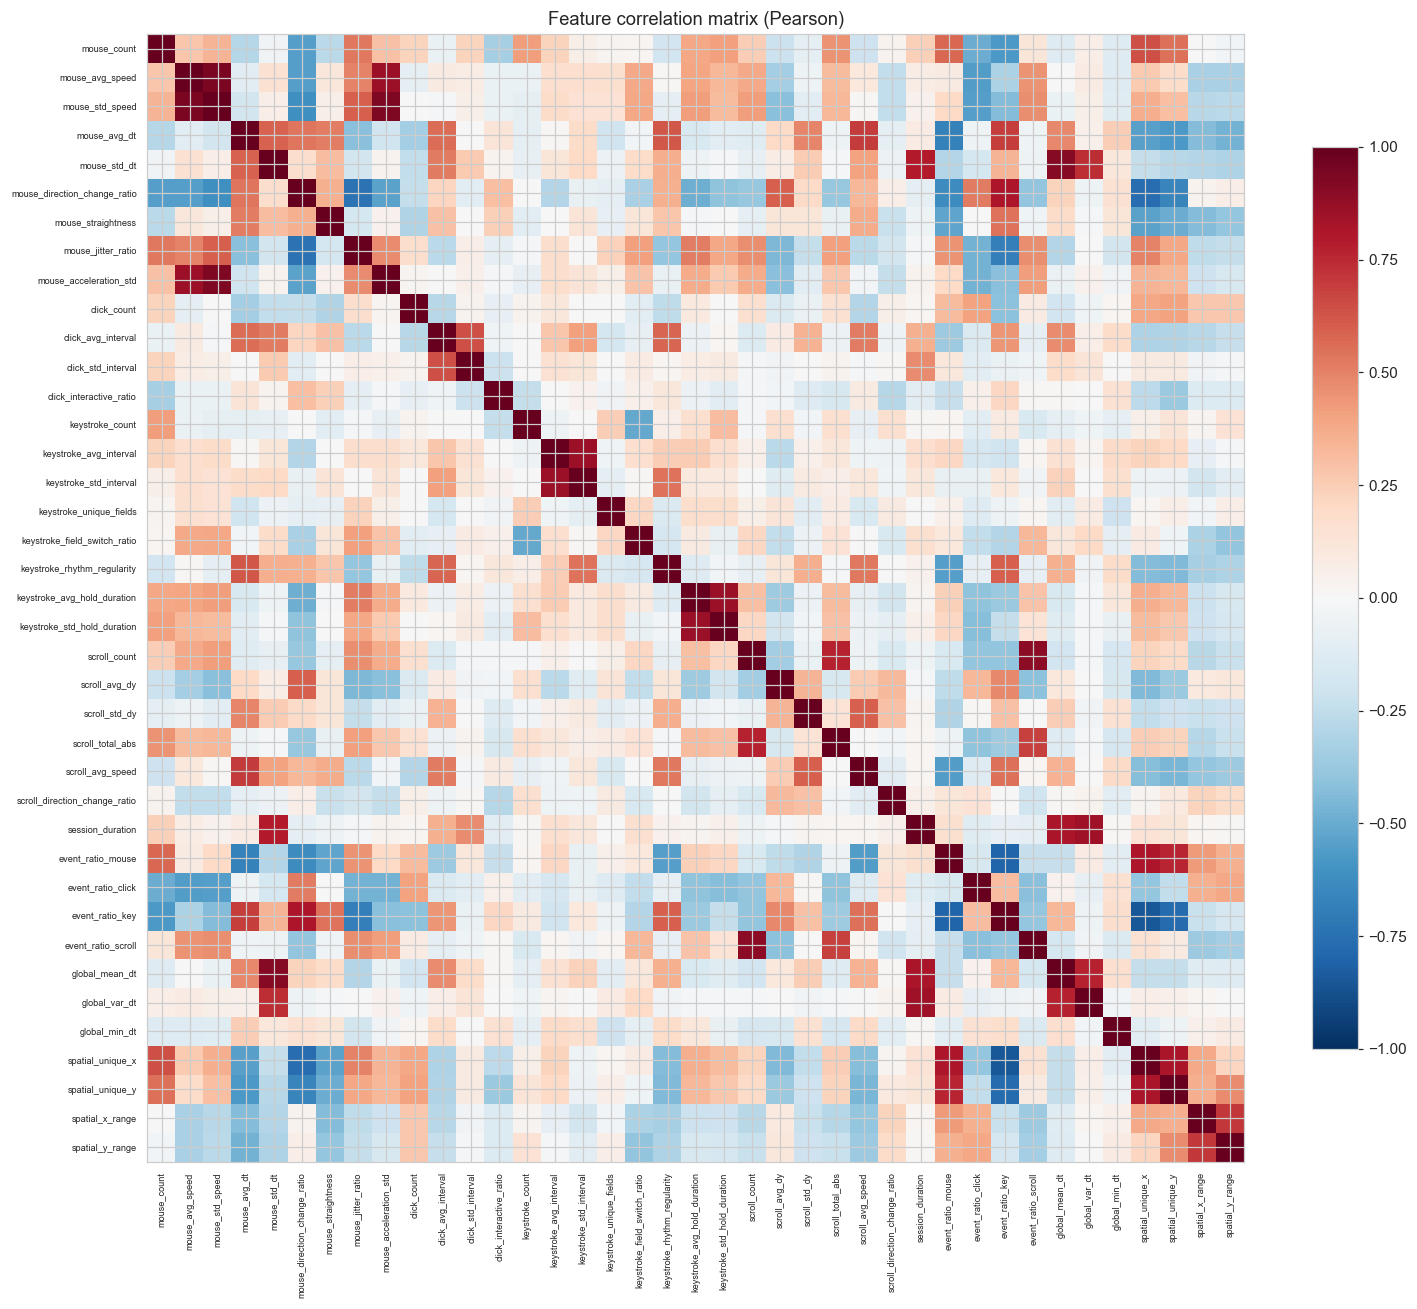

In [ ]:
corr = np.corrcoef(X_all.T)
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(FEATURE_DIM))
ax.set_yticks(range(FEATURE_DIM))
ax.set_xticklabels(FEATURE_NAMES, rotation=90, fontsize=6)
ax.set_yticklabels(FEATURE_NAMES, fontsize=6)
ax.set_title("Feature correlation matrix (Pearson)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clf_04_correlation_matrix.png")
plt.show()

---
## 4. Train / Test Split

We use a stratified 80/20 split. **Only original sessions** go into the split — augmented copies are added to the training set only after the split to prevent data leakage.

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Stratified split on originals only
train_idx, test_idx = train_test_split(
    np.arange(len(originals)),
    test_size=TEST_SIZE,
    stratify=y_all if len(np.unique(y_all)) > 1 else None,
    random_state=RANDOM_STATE,
)

train_sessions_orig = [originals[i] for i in train_idx]
test_sessions_list = [originals[i] for i in test_idx]

# Extract features for the base train and test sets
X_train_orig = extractor.extract_many(train_sessions_orig)
y_train_orig = np.array([s.label for s in train_sessions_orig], dtype=int)
X_test = extractor.extract_many(test_sessions_list)
y_test = np.array([s.label for s in test_sessions_list], dtype=int)

n_h_train = (y_train_orig == 1).sum()
n_b_train = (y_train_orig == 0).sum()
n_h_test = (y_test == 1).sum()
n_b_test = (y_test == 0).sum()

print(f"Train set: {len(y_train_orig)} sessions ({n_h_train}H / {n_b_train}B)")
print(f"Test set : {len(y_test)} sessions ({n_h_test}H / {n_b_test}B)")
print(f"Train feature matrix: {X_train_orig.shape}")
print(f"Test feature matrix : {X_test.shape}")

Train set: 510 sessions (161H / 349B)
Test set : 128 sessions (41H / 87B)
Train feature matrix: (510, 39)
Test feature matrix : (128, 39)


### 4.1 Prepare augmented training data
Add pre-generated augmented bot sessions to the training set (only) for variants that use them.

In [ ]:
# Build augmented training set: originals + pre-generated augmented bot sessions
train_sessions_aug = train_sessions_orig + aug_sessions
X_train_aug = extractor.extract_many(train_sessions_aug)
y_train_aug = np.array([s.label for s in train_sessions_aug], dtype=int)

print(f"Train set with augmented bots: {len(y_train_aug)} sessions")
print(f"  Original train: {len(y_train_orig)}")
print(f"  Augmented bots: {len(aug_sessions)}")

Train set with augmented bots: 3120 sessions
  Original train: 510
  Augmented bots: 2610


---
## 5. Shared Training & Evaluation Helpers

Define reusable functions for training a `HumanLikelihoodClassifier` variant and evaluating it on the held-out test set. Each variant differs only in its `ClassifierConfig`.

In [ ]:
def train_and_evaluate(config, X_train, y_train, X_test, y_test, label):
    """Train a classifier with the given config and return evaluation metrics."""
    print(f"\n{'='*60}")
    print(f"  Training: {label}")
    print(f"{'='*60}")
    print(f"  Train samples: {len(y_train)}  |  Test samples: {len(y_test)}")

    clf = HumanLikelihoodClassifier(config=config)
    clf.fit(X_train, y_train)

    # Predict on test set
    y_pred = clf.predict(X_test)
    y_score = clf.human_score(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_score)
    except ValueError:
        auc = float("nan")

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")

    return {
        "label": label,
        "clf": clf,
        "config": config,
        "y_pred": y_pred,
        "y_score": y_score,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "auc": auc,
        "cm": cm,
    }


def plot_evaluation(result, X_test, y_test, out_path, color="#4C72B0"):
    """Generate a 2x2 evaluation figure: confusion matrix, ROC, score dist, feature importance."""
    label = result["label"]
    clf = result["clf"]
    y_score = result["y_score"]
    y_pred = result["y_pred"]
    cm = result["cm"]
    auc = result["auc"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Confusion matrix heatmap
    ax = axes[0, 0]
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Bot", "Human"]); ax.set_yticklabels(["Bot", "Human"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")
    for i in range(2):
        for j in range(2):
            txt_color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color=txt_color, fontsize=16)

    # ROC curve
    ax = axes[0, 1]
    if not np.isnan(auc):
        fpr, tpr, _ = roc_curve(y_test, y_score)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc:.3f}")
        ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
        ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
        ax.legend(loc="lower right")
    else:
        ax.text(0.5, 0.5, "Not enough classes\nfor ROC curve",
                ha="center", va="center")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")

    # Score distribution
    ax = axes[1, 0]
    human_scores = y_score[y_test == 1]
    bot_scores = y_score[y_test == 0]
    if len(human_scores):
        ax.hist(human_scores, bins=20, range=(0, 1), alpha=0.6,
                label="Human", color="steelblue")
    if len(bot_scores):
        ax.hist(bot_scores, bins=20, range=(0, 1), alpha=0.6,
                label="Bot", color="tomato")
    ax.axvline(x=0.5, color="black", linestyle="--", lw=1, label="Threshold=0.5")
    ax.set_xlabel("Human-Likelihood Score"); ax.set_ylabel("Count")
    ax.set_title("Score Distribution"); ax.legend()

    # Feature importance (top 15)
    ax = axes[1, 1]
    importances = clf.feature_importances(feature_names=FEATURE_NAMES)
    top_names = list(importances.keys())[:15]
    top_scores = [importances[n] for n in top_names]
    top_names.reverse(); top_scores.reverse()
    ax.barh(top_names, top_scores, color=color)
    ax.set_xlabel("Importance")
    ax.set_title("Top 15 Feature Importances")

    fig.suptitle(f"{label}  (n_test={len(y_test)}, acc={result['acc']:.3f}, AUC={auc:.3f})",
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()

---
## 6. Variant 1 — Baseline (No Augmentation)

Train XGBoost with all augmentation disabled. This is the simplest model — no noise injection, no adversarial copies, no label smoothing. Serves as the control to measure how much each augmentation strategy helps.

In [ ]:
# Baseline config: disable all augmentation and label smoothing
baseline_cfg = ClassifierConfig(
    feature_noise_std=0.0,
    n_augment_copies=0,
    adversarial_augment=False,
    label_smooth_alpha=0.0,
    standardize=True,
)

result_baseline = train_and_evaluate(
    baseline_cfg, X_train_orig, y_train_orig, X_test, y_test,
    label="Baseline (no augmentation)",
)


  Training: Baseline (no augmentation)
  Train samples: 510  |  Test samples: 128



  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000
  ROC-AUC   : 1.0000


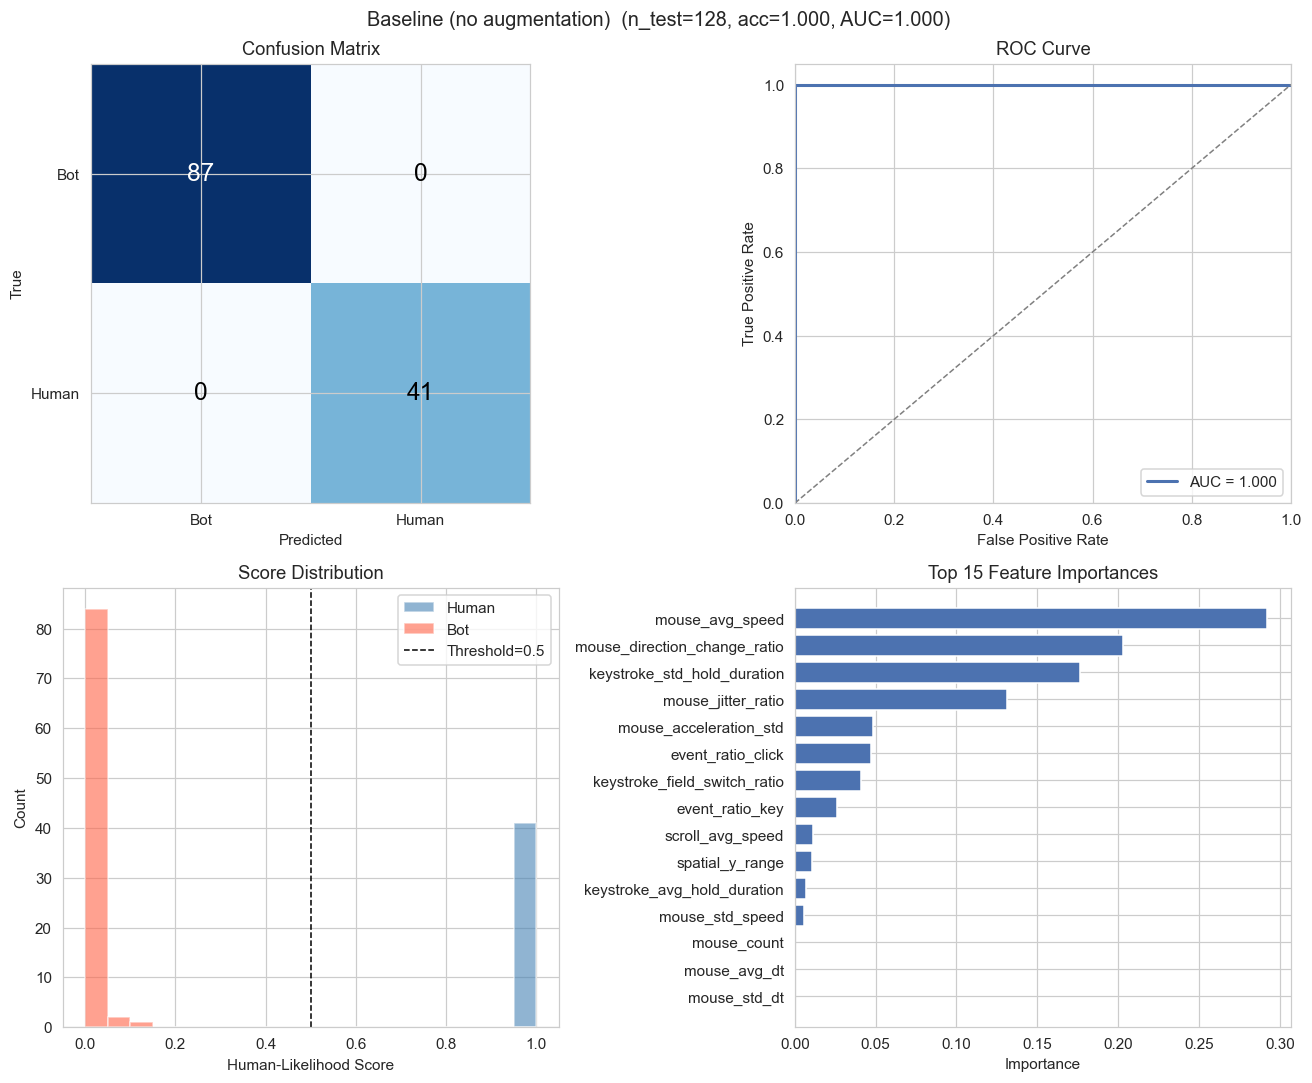

In [ ]:
plot_evaluation(result_baseline, X_test, y_test,
                FIGURES_DIR / "clf_05_baseline_eval.png", color="#4C72B0")

---
## 7. Variant 2 — Noise-Augmented

Enable **multi-copy Gaussian noise augmentation** on the feature vectors. For each training sample, generate `n_augment_copies` noisy copies where noise is scaled to each feature's standard deviation. This exposes the model to more variation and prevents it from memorizing exact feature values.

$$X_{aug} = X + \epsilon, \quad \epsilon \sim \mathcal{N}(0,\; (\sigma_{feat} \cdot \text{noise\_std})^2)$$

In [ ]:
# Noise-augmented config: Gaussian feature noise, no adversarial
noise_cfg = ClassifierConfig(
    feature_noise_std=0.5,       # noise scale relative to feature std
    n_augment_copies=3,          # 3 noisy copies per sample
    adversarial_augment=False,   # no adversarial humanization
    label_smooth_alpha=0.0,
    standardize=True,
)

result_noise = train_and_evaluate(
    noise_cfg, X_train_orig, y_train_orig, X_test, y_test,
    label="Noise-Augmented",
)


  Training: Noise-Augmented
  Train samples: 510  |  Test samples: 128



  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000
  ROC-AUC   : 1.0000


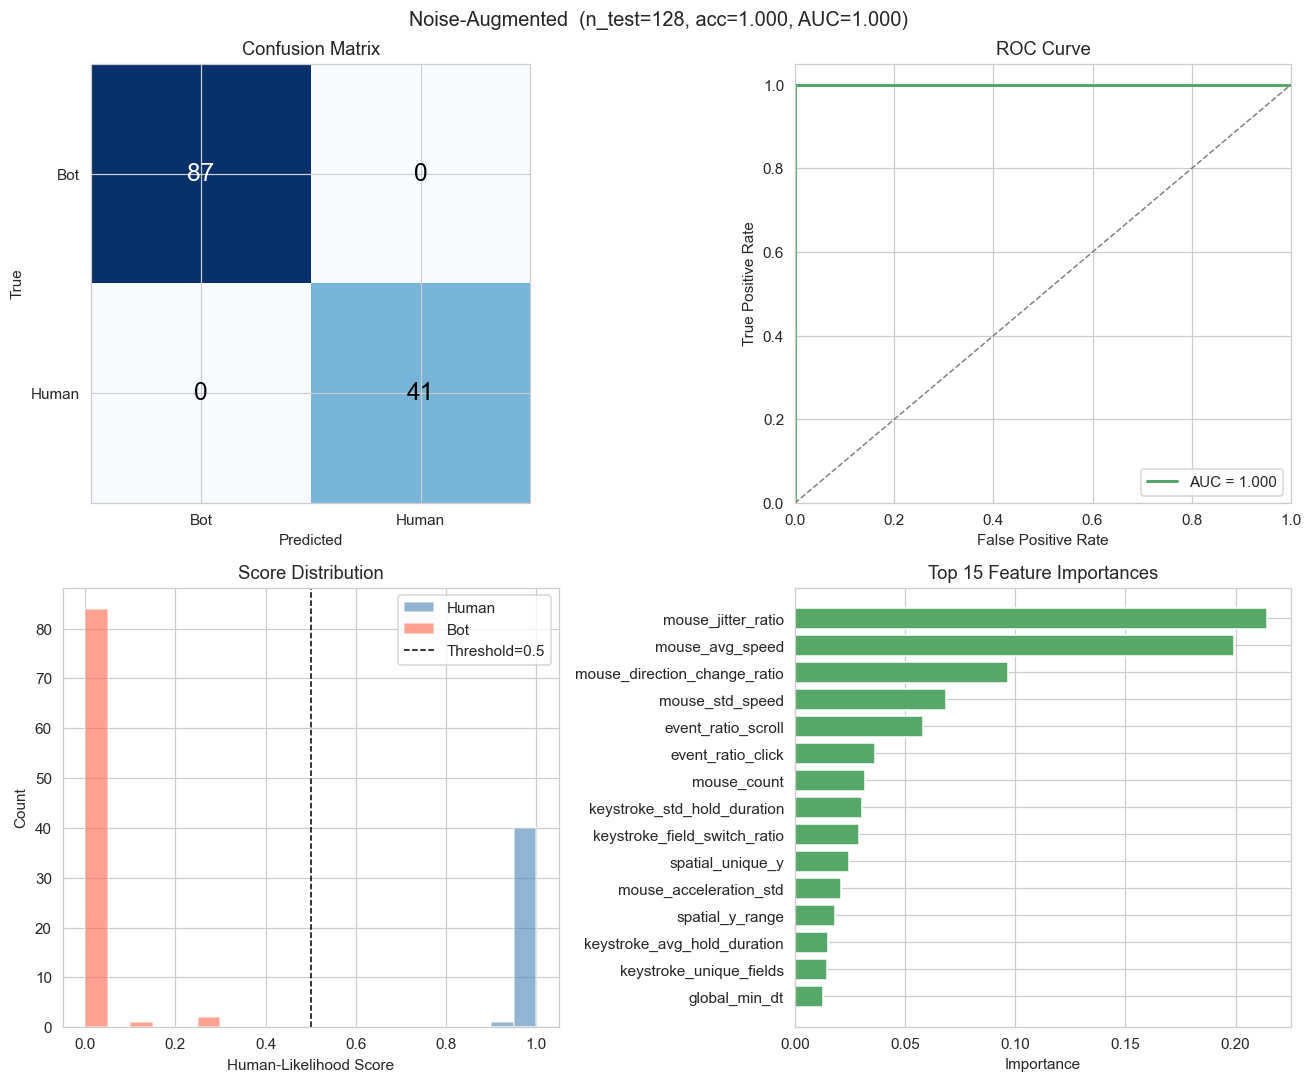

In [ ]:
plot_evaluation(result_noise, X_test, y_test,
                FIGURES_DIR / "clf_06_noise_eval.png", color="#55A868")

---
## 8. Variant 3 — Adversarial-Augmented

Enable **adversarial bot humanization** at the feature level. During training, `n_adversarial_copies` copies of each bot sample are created by blending their features toward the human class mean. This forces the classifier to learn deeper behavioral patterns rather than relying on trivially separable surface-level differences.

$$X_{adv} = X_{bot} + \beta \cdot (\mu_{human} - X_{bot}) + \epsilon_{noise}$$

where $\beta \sim U(\text{blend\_lo}, \text{blend\_hi})$.

This variant also uses the **pre-generated raw-telemetry augmented sessions** from `data/bot_augmented/` (the three-tier pipeline: easy/medium/hard humanization at the event level).

In [ ]:
# Adversarial-augmented config: feature-level humanization + raw-telemetry augmented sessions
adversarial_cfg = ClassifierConfig(
    feature_noise_std=0.0,           # no general noise
    n_augment_copies=0,
    adversarial_augment=True,        # enable feature-level adversarial humanization
    n_adversarial_copies=2,
    adversarial_blend_range=(0.2, 0.6),
    adversarial_noise_std=0.3,
    label_smooth_alpha=0.0,
    standardize=True,
)

# Use the augmented training set (originals + pre-generated augmented bots)
result_adversarial = train_and_evaluate(
    adversarial_cfg, X_train_aug, y_train_aug, X_test, y_test,
    label="Adversarial-Augmented",
)


  Training: Adversarial-Augmented
  Train samples: 3120  |  Test samples: 128
  [adversarial] Added 5918 humanized bot samples (blend=0.2-0.6, noise_std=0.3)



  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000
  ROC-AUC   : 1.0000


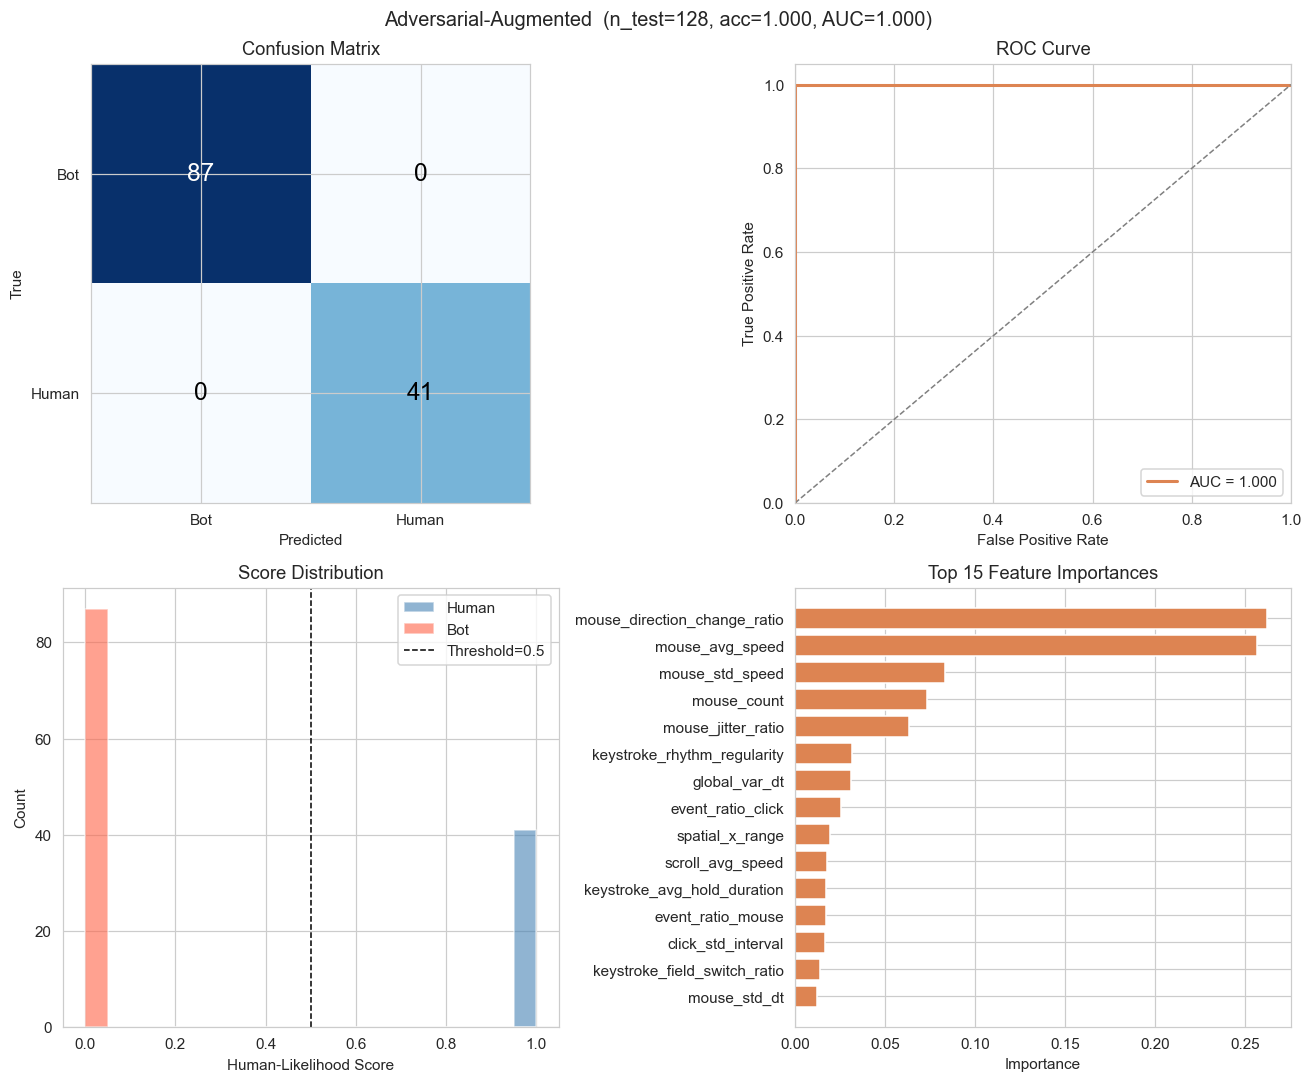

In [ ]:
plot_evaluation(result_adversarial, X_test, y_test,
                FIGURES_DIR / "clf_07_adversarial_eval.png", color="#DD8452")

---
## 9. Variant 4 — Full Pipeline (Default Config)

The full training pipeline combines **all strategies**: noise augmentation, adversarial humanization, label smoothing, and standardization. This is the default `ClassifierConfig` used by `train_classifier.py` and represents the production model.

| Strategy | Purpose |
|---|---|
| Feature noise (std=0.5, 3 copies) | Broaden decision boundaries, reduce overfitting |
| Adversarial humanization (2 copies, blend 0.2-0.6) | Force learning of deep behavioral patterns |
| Label smoothing (alpha=0.05) | Calibrate probability outputs, reduce overconfidence |
| Feature standardization | Ensure uniform noise/augmentation across features |

In [ ]:
# Full pipeline: default ClassifierConfig (all augmentations enabled)
full_cfg = ClassifierConfig()  # uses all defaults from rl_captcha/config.py

# Use the augmented training set for maximum data
result_full = train_and_evaluate(
    full_cfg, X_train_aug, y_train_aug, X_test, y_test,
    label="Full Pipeline (default config)",
)


  Training: Full Pipeline (default config)
  Train samples: 3120  |  Test samples: 128
  [adversarial] Added 5918 humanized bot samples (blend=0.2-0.6, noise_std=0.3)



  Accuracy  : 0.9922
  Precision : 0.9762
  Recall    : 1.0000
  F1 Score  : 0.9880
  ROC-AUC   : 1.0000


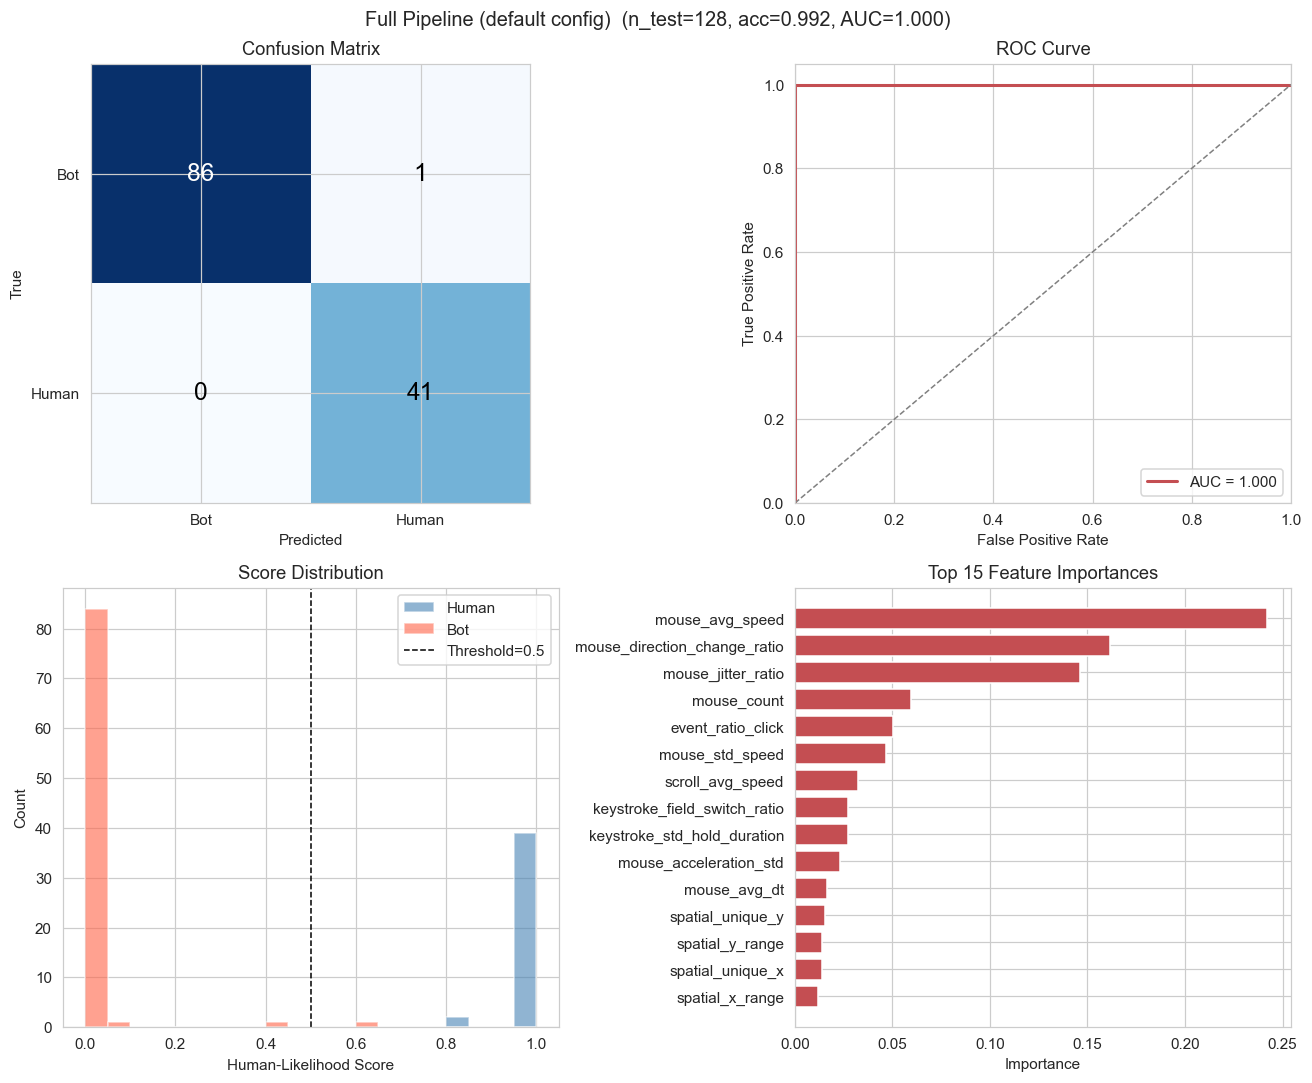

In [ ]:
plot_evaluation(result_full, X_test, y_test,
                FIGURES_DIR / "clf_08_full_pipeline_eval.png", color="#C44E52")

---
## 10. Side-by-Side Comparison

Overlay all four variants on the same axes to directly compare their performance.

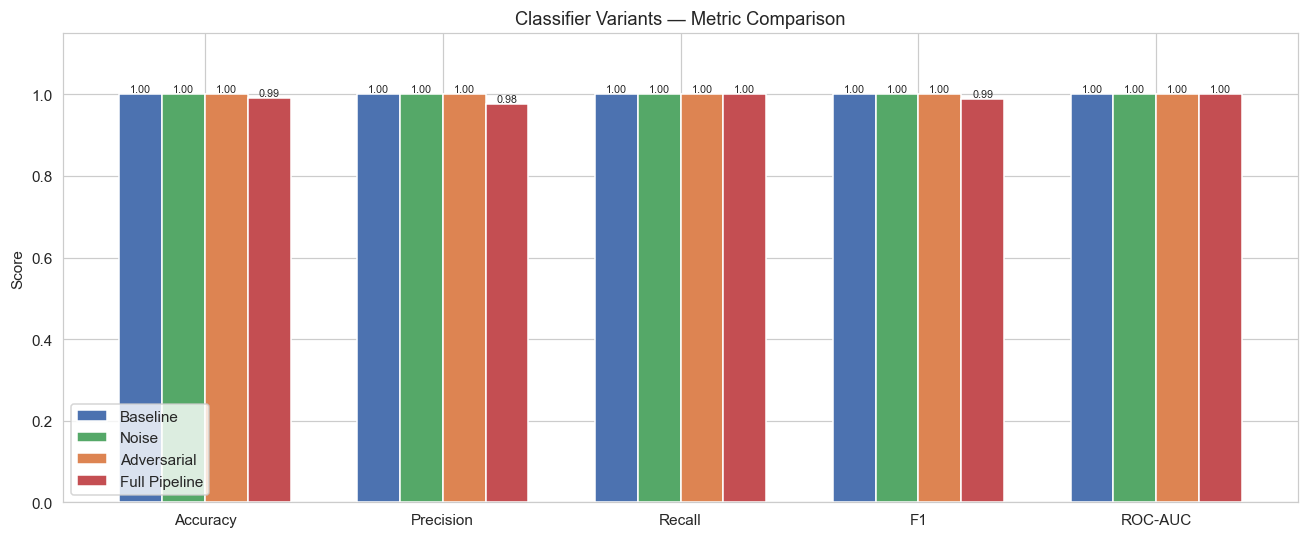

In [ ]:
# Collect all results for comparison
all_results = [result_baseline, result_noise, result_adversarial, result_full]
variant_colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

# --- Bar chart: key metrics side by side ---
metrics_to_compare = ["acc", "prec", "rec", "f1", "auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
labels = [r["label"] for r in all_results]
# Shorten labels for the x-axis
short_labels = ["Baseline", "Noise", "Adversarial", "Full Pipeline"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_to_compare))
width = 0.18

for i, (result, color, short) in enumerate(zip(all_results, variant_colors, short_labels)):
    values = [result[m] for m in metrics_to_compare]
    bars = ax.bar(x + i * width, values, width, label=short, color=color)
    # Annotate each bar
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Classifier Variants — Metric Comparison")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clf_09_metric_comparison.png")
plt.show()

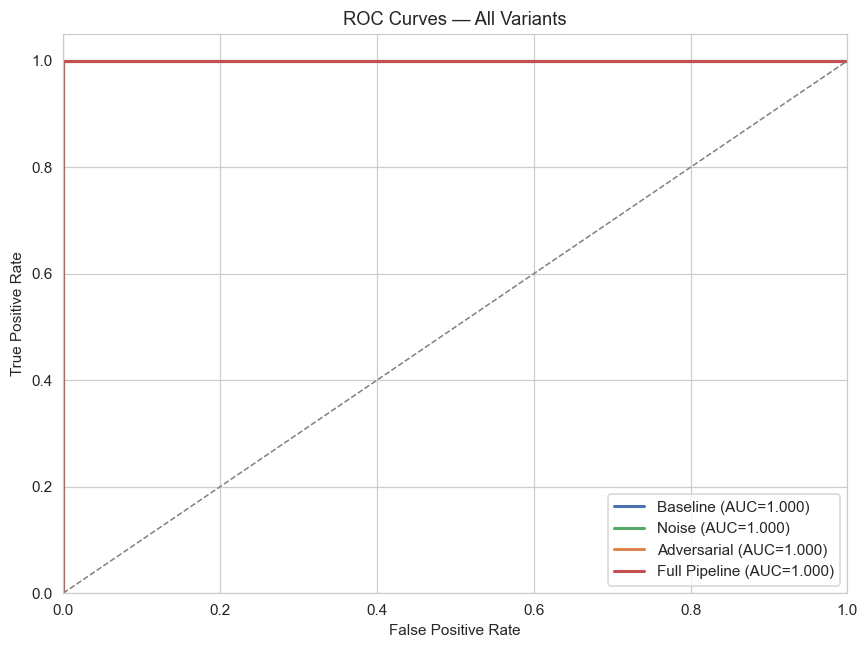

In [ ]:
# --- Overlaid ROC curves ---
fig, ax = plt.subplots(figsize=(8, 6))
for result, color, short in zip(all_results, variant_colors, short_labels):
    y_score = result["y_score"]
    auc = result["auc"]
    if not np.isnan(auc):
        fpr, tpr, _ = roc_curve(y_test, y_score)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{short} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Variants")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clf_10_roc_comparison.png")
plt.show()

In [ ]:
# --- Summary table ---
print(f"\n{'Variant':<30s} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print("-" * 72)
for result in all_results:
    print(f"{result['label']:<30s} "
          f"{result['acc']:>7.4f} {result['prec']:>7.4f} "
          f"{result['rec']:>7.4f} {result['f1']:>7.4f} {result['auc']:>7.4f}")


Variant                            Acc    Prec     Rec      F1     AUC
------------------------------------------------------------------------
Baseline (no augmentation)      1.0000  1.0000  1.0000  1.0000  1.0000
Noise-Augmented                 1.0000  1.0000  1.0000  1.0000  1.0000
Adversarial-Augmented           1.0000  1.0000  1.0000  1.0000  1.0000
Full Pipeline (default config)  0.9922  0.9762  1.0000  0.9880  1.0000


---
## 11. Cross-Validation of the Full Pipeline

Run 5-fold stratified cross-validation on the full pipeline to get a more robust estimate of generalization performance.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_metrics = defaultdict(list)
fold_num = 0

for fold_train_idx, fold_val_idx in skf.split(X_all, y_all):
    fold_num += 1
    X_tr, X_va = X_all[fold_train_idx], X_all[fold_val_idx]
    y_tr, y_va = y_all[fold_train_idx], y_all[fold_val_idx]

    clf_cv = HumanLikelihoodClassifier(config=ClassifierConfig())
    clf_cv.fit(X_tr, y_tr, X_val=X_va, y_val=y_va)

    y_pred_cv = clf_cv.predict(X_va)
    y_score_cv = clf_cv.human_score(X_va)

    cv_metrics["acc"].append(accuracy_score(y_va, y_pred_cv))
    cv_metrics["f1"].append(f1_score(y_va, y_pred_cv, zero_division=0))
    try:
        cv_metrics["auc"].append(roc_auc_score(y_va, y_score_cv))
    except ValueError:
        cv_metrics["auc"].append(float("nan"))

    print(f"  Fold {fold_num}: acc={cv_metrics['acc'][-1]:.4f}  "
          f"f1={cv_metrics['f1'][-1]:.4f}  auc={cv_metrics['auc'][-1]:.4f}")

print(f"\n  Mean +/- Std:")
for metric in ["acc", "f1", "auc"]:
    vals = np.array(cv_metrics[metric])
    print(f"    {metric:>4s}: {vals.mean():.4f} +/- {vals.std():.4f}")

  [adversarial] Added 698 humanized bot samples (blend=0.2-0.6, noise_std=0.3)


  Fold 1: acc=1.0000  f1=1.0000  auc=1.0000
  [adversarial] Added 698 humanized bot samples (blend=0.2-0.6, noise_std=0.3)


  Fold 2: acc=1.0000  f1=1.0000  auc=1.0000
  [adversarial] Added 696 humanized bot samples (blend=0.2-0.6, noise_std=0.3)


  Fold 3: acc=0.9922  f1=0.9877  auc=1.0000
  [adversarial] Added 698 humanized bot samples (blend=0.2-0.6, noise_std=0.3)


  Fold 4: acc=0.9921  f1=0.9873  auc=1.0000
  [adversarial] Added 698 humanized bot samples (blend=0.2-0.6, noise_std=0.3)


  Fold 5: acc=0.9843  f1=0.9750  auc=0.9997

  Mean +/- Std:
     acc: 0.9937 +/- 0.0059
      f1: 0.9900 +/- 0.0094
     auc: 0.9999 +/- 0.0001


/var/folders/hs/jrn5l5cd2qg7_07wv16sfj5c0000gn/T/ipykernel_58887/4287559411.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cv_data, labels=cv_labels_plot, patch_artist=True)


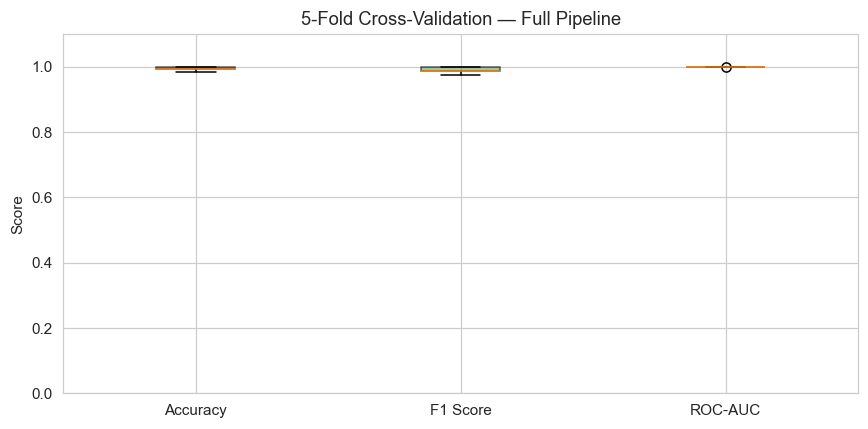

In [ ]:
# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(8, 4))
cv_data = [cv_metrics["acc"], cv_metrics["f1"], cv_metrics["auc"]]
cv_labels_plot = ["Accuracy", "F1 Score", "ROC-AUC"]
bp = ax.boxplot(cv_data, labels=cv_labels_plot, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#55A868", "#C44E52"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylim(0, 1.1)
ax.set_title("5-Fold Cross-Validation — Full Pipeline")
ax.set_ylabel("Score")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "clf_11_cross_validation.png")
plt.show()

---
## 12. Save the Best Model

Save the full-pipeline model to `classifier/models/` for use by the RL environment and the live system.

In [ ]:
# Save the full-pipeline model
SAVE_DIR = NOTEBOOK_DIR / "classifier" / "models" / "xgb_notebook"
result_full["clf"].save(SAVE_DIR)

# Also print ranked feature importances
importances = result_full["clf"].feature_importances(feature_names=FEATURE_NAMES)
print("\n--- Feature Importances (descending) ---")
for name, score in importances.items():
    bar = "#" * int(score * 40)
    print(f"  {name:<40s} {score:.4f}  {bar}")

[HumanLikelihoodClassifier] Saved to /Users/martintran/senior_project/group-project-team-25/src/classifier/models/xgb_notebook

--- Feature Importances (descending) ---
  mouse_avg_speed                          0.2422  #########
  mouse_direction_change_ratio             0.1613  ######
  mouse_jitter_ratio                       0.1461  #####
  mouse_count                              0.0595  ##
  event_ratio_click                        0.0503  ##
  mouse_std_speed                          0.0469  #
  scroll_avg_speed                         0.0326  #
  keystroke_field_switch_ratio             0.0274  #
  keystroke_std_hold_duration              0.0271  #
  mouse_acceleration_std                   0.0233  
  mouse_avg_dt                             0.0168  
  spatial_unique_y                         0.0154  
  spatial_y_range                          0.0139  
  spatial_unique_x                         0.0138  
  spatial_x_range                          0.0119  
  event_ratio_mouse    

---
## 13. Summary & Next Steps

**What we built**
- Loaded all human / bot / augmented-bot sessions from `src/data/` and visualized the dataset composition.
- Extracted 39 session-level telemetry features and explored their distributions and correlations.
- Trained **four XGBoost classifier variants** with different augmentation strategies:
  - **Baseline** — no augmentation (control)
  - **Noise-Augmented** — multi-copy Gaussian noise on features
  - **Adversarial-Augmented** — humanized bot copies + pre-generated augmented sessions
  - **Full Pipeline** — all strategies combined (production default)
- Evaluated each variant with confusion matrices, ROC curves, score distributions, and feature importances.
- Ran 5-fold cross-validation on the full pipeline for a robust performance estimate.
- Saved the full-pipeline model to `classifier/models/xgb_notebook/`.

**All figures saved to:** `notebook_figures/` (prefixed with `clf_`)

**To reproduce with hyperparameter tuning**, run from the repo root:
```bash
python src/classifier/scripts/train_classifier.py \
    --data-dir data/ \
    --adversarial-augment \
    --tune --n-trials 50 \
    --output-dir src/classifier/models/xgb_tuned
```